In [ ]:
import pandas as pd

# Switch between the two datasets by changing this one line.
DATASET_PATH = 'CICIDS2017_sample_km.csv'
# DATASET_PATH = 'IoT_Network_Intrusion_Dataset_0.1.csv'

data = pd.read_csv(DATASET_PATH)

print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

print("\nFirst 5 rows:")
display(data.head())

In [2]:
print(data.info())

print("\nClass distribution:")
print(data['Label'].value_counts())

print("\nClass distribution (%):")
print(data['Label'].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35941 entries, 0 to 35940
Data columns (total 86 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   expiration_id                 35941 non-null  float64
 1   src_ip                        35941 non-null  float64
 2   src_mac                       35941 non-null  float64
 3   src_oui                       35941 non-null  float64
 4   src_port                      35941 non-null  float64
 5   dst_ip                        35941 non-null  float64
 6   dst_mac                       35941 non-null  float64
 7   dst_oui                       35941 non-null  float64
 8   dst_port                      35941 non-null  float64
 9   protocol                      35941 non-null  float64
 10  ip_version                    35941 non-null  float64
 11  vlan_id                       35941 non-null  float64
 12  tunnel_id                     35941 non-null  float64
 13  b

## Label encoding check
Make this notebook safe to run regardless of whether `Label` is already integer-encoded (as it is in this pre-sampled CICIDS2017 file) or still text categories. The raw-XGBoost cells later on cast labels to `int32`, so encoding this once up front — and deriving `N_CLASSES`/`ALL_CLASSES` from the data instead of hardcoding `7` everywhere — avoids a crash and keeps every downstream cell consistent.

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("Label dtype:", data['Label'].dtype)

raw_values = np.sort(data['Label'].unique())
is_contiguous = pd.api.types.is_numeric_dtype(data['Label']) and list(raw_values) == list(range(len(raw_values)))

if is_contiguous:
    label_encoder = None
    print("\nLabels are already numeric and contiguous (0..N-1) -- no encoding needed.")
else:
    label_encoder = LabelEncoder()
    data['Label'] = label_encoder.fit_transform(data['Label'])

    reason = "were text" if not pd.api.types.is_numeric_dtype(raw_values) else "were numeric but not contiguous (0..N-1)"
    print(f"\nLabels {reason} -- re-encoded to contiguous integers:")
    for i, cls in enumerate(label_encoder.classes_):
        print(f"  {i} -> {cls}")

N_CLASSES = int(data['Label'].nunique())
ALL_CLASSES = np.sort(data['Label'].unique())

print("\nNumber of classes:", N_CLASSES)
print("Class values:", ALL_CLASSES)

In [4]:
from sklearn.model_selection import train_test_split

# Features and target
X = data.drop(columns=['Label'])
y = data['Label']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

X_train shape: (28752, 85)
X_test shape: (7189, 85)
y_train shape: (28752,)
y_test shape: (7189,)

Training class distribution:
Label
0       66
1     3791
2     2737
3     4645
4       72
5     2488
6      835
7     6157
8     2952
9     1262
10    1518
11    2229
Name: count, dtype: int64

Testing class distribution:
Label
0       16
1      948
2      684
3     1162
4       18
5      622
6      209
7     1539
8      738
9      315
10     380
11     558
Name: count, dtype: int64


## Centralized baseline models
One model per algorithm trained on the full training set. These are the reference points that the federated (IID / Non-IID) results are compared against.


3-Fold Macro F1 Scores: [0.98258022 0.97865999 0.99563359]
Mean CV Macro F1: 0.9856246016595196
CV Time: 9.120291948318481 seconds

Training time: 1.0761349201202393 seconds

Prediction time: 0.0057103633880615234 seconds
Prediction time per sample: 0.000794319569907014 ms

DECISION TREE RESULTS
Accuracy: 0.9991653915704548
Macro Precision: 0.9940175771976131
Macro Recall: 0.9897730437204122
Macro F1: 0.9918330251642798
Weighted F1: 0.9991594771708413

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00       948
           2       1.00      1.00      1.00       684
           3       1.00      1.00      1.00      1162
           4       0.94      0.89      0.91        18
           5       1.00      1.00      1.00       622
           6       1.00      1.00      1.00       209
           7       1.00      1.00      1.00      1539
           8       1.00      1.0

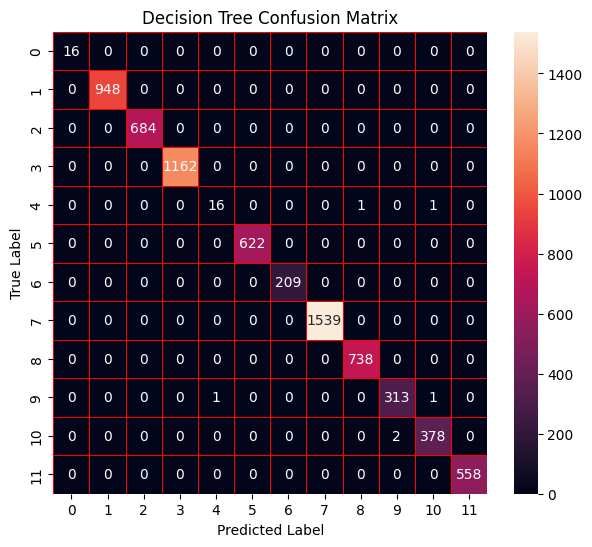


Tree depth: 18
Number of leaves: 84
CPU times: user 1.63 s, sys: 88.2 ms, total: 1.72 s
Wall time: 11.9 s


In [5]:
%%time

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. Decision Tree
# ============================================================

dt = DecisionTreeClassifier(
    random_state=0,
    class_weight='balanced'
)


# ============================================================
# 2. 3-Fold Stratified Cross-Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

start = time.time()

cv_scores = cross_val_score(
    dt,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

cv_time = time.time() - start


print("\n3-Fold Macro F1 Scores:", cv_scores)
print("Mean CV Macro F1:", np.mean(cv_scores))
print("CV Time:", cv_time, "seconds")


# ============================================================
# 3. Train on complete training set
# ============================================================

start = time.time()

dt.fit(X_train, y_train)

training_time = time.time() - start

print("\nTraining time:", training_time, "seconds")


# ============================================================
# 4. Test prediction
# ============================================================

start = time.time()

y_pred = dt.predict(X_test)

prediction_time = time.time() - start

print("\nPrediction time:", prediction_time, "seconds")
print(
    "Prediction time per sample:",
    prediction_time / len(X_test) * 1000,
    "ms"
)


# ============================================================
# 5. Test evaluation
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n==============================")
print("DECISION TREE RESULTS")
print("==============================")
print("Accuracy:", accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


# ============================================================
# 6. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', linewidths=0.5, linecolor='red')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Decision Tree Confusion Matrix")
plt.show()

print("\nTree depth:", dt.get_depth())
print("Number of leaves:", dt.get_n_leaves())

centralized_dt_results = {
    "Model": "Decision Tree",
    "Setting": "Centralized",
    "Accuracy": accuracy,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1
}

### Fair-comparison centralized Random Forest (300 trees)
The federated Random Forest below pools 3 clients x 100 trees = 300 trees into one ensemble. This 300-tree centralized run matches the federated model's total tree budget so any gap between them reflects the effect of partitioning the data across clients, not just having more trees.

In [7]:
%%time

rf_300 = RandomForestClassifier(
    n_estimators=300,
    random_state=0,
    class_weight='balanced',
    n_jobs=-1
)

start = time.time()
rf_300.fit(X_train, y_train)
training_time_300 = time.time() - start

y_pred_300 = rf_300.predict(X_test)

accuracy_300 = accuracy_score(y_test, y_pred_300)
macro_precision_300 = precision_score(y_test, y_pred_300, average='macro', zero_division=0)
macro_recall_300 = recall_score(y_test, y_pred_300, average='macro', zero_division=0)
macro_f1_300 = f1_score(y_test, y_pred_300, average='macro', zero_division=0)
weighted_f1_300 = f1_score(y_test, y_pred_300, average='weighted', zero_division=0)

print("==============================")
print("RANDOM FOREST RESULTS (300 trees, fair-comparison baseline)")
print("==============================")
print("Training time:", training_time_300, "seconds")
print("Accuracy:", accuracy_300)
print("Macro F1:", macro_f1_300)
print("Weighted F1:", weighted_f1_300)

centralized_rf_300_results = {
    "Model": "Random Forest",
    "Setting": "Centralized (300 trees)",
    "Accuracy": accuracy_300,
    "Macro Precision": macro_precision_300,
    "Macro Recall": macro_recall_300,
    "Macro F1": macro_f1_300,
    "Weighted F1": weighted_f1_300
}

RANDOM FOREST RESULTS (300 trees, fair-comparison baseline)
Training time: 11.278769969940186 seconds
Accuracy: 0.9987480873556823
Macro F1: 0.9958598065132942
Weighted F1: 0.9987509144293419
CPU times: user 18.9 s, sys: 114 ms, total: 19 s
Wall time: 11.5 s


In [8]:
!pip install xgboost -q

3-Fold Macro F1 Scores: [0.98275537 0.98958815 0.99260382]
Mean CV Macro F1: 0.9883157789057324

Training time: 11.220567464828491 seconds

XGBOOST RESULTS
Accuracy: 0.9995826957852274
Macro Precision: 0.9952625102759032
Macro Recall: 0.9992601453127768
Macro F1: 0.997201158775304
Weighted F1: 0.9995844131191907

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00       948
           2       1.00      1.00      1.00       684
           3       1.00      1.00      1.00      1162
           4       0.95      1.00      0.97        18
           5       1.00      1.00      1.00       622
           6       1.00      1.00      1.00       209
           7       1.00      1.00      1.00      1539
           8       1.00      1.00      1.00       738
           9       1.00      1.00      1.00       315
          10       1.00      1.00      1.00       380
          11 

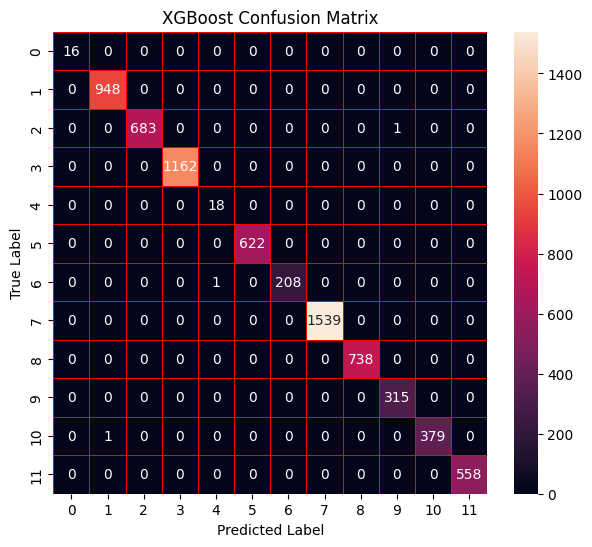

CPU times: user 1min 12s, sys: 239 ms, total: 1min 13s
Wall time: 58.1 s


In [9]:
%%time

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. XGBoost
# ============================================================

xgb_clf = XGBClassifier(
    objective='multi:softmax',
    num_class=N_CLASSES,
    n_estimators=100,
    random_state=0,
    eval_metric='mlogloss'
)


# ============================================================
# 2. 3-Fold Stratified Cross-Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

xgb_cv_scores = cross_val_score(
    xgb_clf,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print("3-Fold Macro F1 Scores:", xgb_cv_scores)
print("Mean CV Macro F1:", np.mean(xgb_cv_scores))


# ============================================================
# 3. Train and evaluate
# ============================================================

start = time.time()
xgb_clf.fit(X_train, y_train)
training_time = time.time() - start

print("\nTraining time:", training_time, "seconds")

y_pred = xgb_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n==============================")
print("XGBOOST RESULTS")
print("==============================")
print("Accuracy:", accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', linewidths=0.5, linecolor='red')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost Confusion Matrix")
plt.show()

centralized_xgb_results = {
    "Model": "XGBoost",
    "Setting": "Centralized",
    "Accuracy": accuracy,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1
}

In [10]:
!pip install lightgbm -q

3-Fold Macro F1 Scores: [0.27518134 0.98577662 0.22233896]
Mean CV Macro F1: 0.494432307287731

Training time: 8.916746139526367 seconds

LIGHTGBM RESULTS
Accuracy: 0.9988871887606064
Macro Precision: 0.9943267841901763
Macro Recall: 0.989296157059315
Macro F1: 0.9914613120851054
Weighted F1: 0.9988787861164915

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      1.00      1.00       948
           2       1.00      1.00      1.00       684
           3       1.00      1.00      1.00      1162
           4       1.00      0.89      0.94        18
           5       1.00      1.00      1.00       622
           6       1.00      1.00      1.00       209
           7       1.00      1.00      1.00      1539
           8       1.00      1.00      1.00       738
           9       1.00      0.98      0.99       315
          10       1.00      1.00      1.00       380
          11  

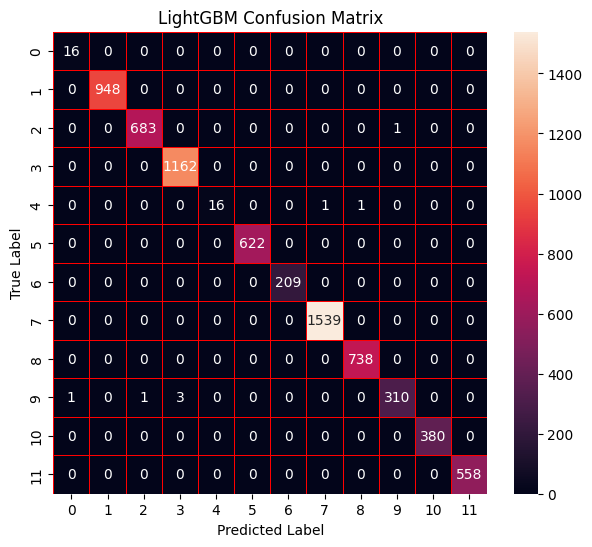

CPU times: user 33 s, sys: 317 ms, total: 33.3 s
Wall time: 45.3 s


In [11]:
%%time

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

lgbm_clf = LGBMClassifier(
    objective='multiclass',
    num_class=N_CLASSES,
    n_estimators=100,
    random_state=0,
    verbosity=-1
)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

lgbm_cv_scores = cross_val_score(
    lgbm_clf,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print("3-Fold Macro F1 Scores:", lgbm_cv_scores)
print("Mean CV Macro F1:", np.mean(lgbm_cv_scores))

start = time.time()
lgbm_clf.fit(X_train, y_train)
training_time = time.time() - start

print("\nTraining time:", training_time, "seconds")

y_pred = lgbm_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n==============================")
print("LIGHTGBM RESULTS")
print("==============================")
print("Accuracy:", accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', linewidths=0.5, linecolor='red')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("LightGBM Confusion Matrix")
plt.show()

centralized_lgbm_results = {
    "Model": "LightGBM",
    "Setting": "Centralized",
    "Accuracy": accuracy,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1
}

## Federated learning utilities

These helpers implement **histogram-based federated tree learning**, replacing the ensemble-pooling approach previously used in this notebook (independently training a full model per client, then combining outputs once at the end). The key structural difference: no client ever trains a complete local model. Instead, at every node of every tree, each client computes a small histogram over its own local rows -- class counts for Decision Tree / Random Forest, or gradient/Hessian sums for boosting -- and sends only that histogram to the server. The server sums the histograms across clients and picks the split from the aggregated totals. Split-finding itself is federated and round-based, not a one-shot combination of independently-trained models.

The same core split-finding mechanism is reused for all four models below, parameterized by:
- **statistic aggregated**: class counts (Decision Tree, Random Forest) vs. gradient/Hessian sums (boosting)
- **how many trees, and how they're grown**: a single tree (Decision Tree); many bagged trees with per-client bootstrap resampling + random feature subsets per split (Random Forest); or many boosted trees grown **level-wise** (mirroring XGBoost's depth-wise growth) or **leaf-wise / best-first** (mirroring LightGBM's leaf-wise growth under a `num_leaves` budget)

**On hyperparameters:** feature binning (`n_bins`), max tree depth, and how many trees/rounds are grown are all capped below for tractability -- this is a pure-Python/NumPy implementation, not a compiled tree-building loop, so it is slower per tree than scikit-learn/XGBoost/LightGBM's C++ internals. These defaults were tuned and timed against a similarly-sized local IDS dataset (CICIDS2017 sample, ~27k rows / 77 features); reduce `n_bins`, `n_trees`, or `n_rounds` below if this runs too slowly on the dataset loaded at the top of this notebook.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def check_class_coverage(clients, all_classes, label=""):
    """Print which classes (if any) each client is missing."""
    all_classes = list(all_classes)
    any_missing = False

    title = f"Class coverage check ({label})" if label else "Class coverage check"
    print("=" * 60)
    print(title)
    print("=" * 60)

    for client in clients:
        present = sorted(client["y"].unique())
        missing = [c for c in all_classes if c not in present]

        status = "OK" if not missing else f"MISSING {missing}"
        print(f"Client {client['client_id']}: {len(client['y'])} samples -> {status}")

        if missing:
            any_missing = True

    if any_missing:
        print(
            "\nAt least one client is missing one or more classes. The "
            "federated histogram split-finding below aggregates class/"
            "gradient statistics across all clients before picking a split, "
            "so this is handled safely -- a client simply contributes zero "
            "to the histogram bins for a class it never saw."
        )
    else:
        print("\nAll clients have samples from every class.")

    return any_missing


# Master results table -- every centralized/federated experiment appends
# one row here so we can answer "which performs best" at the end.
all_results = []


def record_result(model_name, setting, y_true, y_pred, extra=None):
    result = {
        "Model": model_name,
        "Setting": setting,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    if extra:
        result.update(extra)

    all_results.append(result)

    print(
        f"[{model_name} | {setting}] "
        f"Accuracy={result['Accuracy']:.4f}  Macro F1={result['Macro F1']:.4f}"
    )
    return result


# Record the centralized baselines computed above.
for centralized_result in (
    centralized_dt_results,
    centralized_rf_300_results,
    centralized_xgb_results,
    centralized_lgbm_results,
):
    all_results.append(centralized_result)

print("\nRecorded", len(all_results), "centralized baseline results.")


In [ ]:
# ============================================================
# Shared federated histogram-tree infrastructure
# ============================================================
# Binning is the only thing that needs to be agreed globally before
# clients start reporting histograms: it fixes the candidate split
# thresholds every client bins its local rows into. In a real
# cross-silo deployment this would come from a privacy-preserving
# quantile sketch (clients report local quantiles, the server merges
# them); here we compute it once from the pooled training features,
# since it only fixes bin *boundaries* -- the histograms computed at
# every actual split during training are still aggregated across
# clients, never sent as raw rows.

def make_global_bin_edges(X_values, n_bins=32):
    n_features = X_values.shape[1]
    edges = []
    qs = np.linspace(0, 1, n_bins + 1)[1:-1]
    for f in range(n_features):
        col = X_values[:, f]
        col = col[np.isfinite(col)]
        edges.append(np.quantile(col, qs) if len(col) else np.zeros(n_bins - 1))
    return edges


def bin_features(X_values, bin_edges):
    n_samples, n_features = X_values.shape
    binned = np.empty((n_samples, n_features), dtype=np.int32)
    for f in range(n_features):
        binned[:, f] = np.digitize(X_values[:, f], bin_edges[f])
    return binned


class Leaf:
    __slots__ = ("output",)

    def __init__(self, output):
        self.output = output


class Node:
    __slots__ = ("feature", "threshold", "left", "right")

    def __init__(self, feature, threshold, left, right):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right


def predict_batch(tree, X, out_width):
    """Vectorized tree traversal: batches samples through the tree by
    boolean masking at each node instead of looping row by row."""
    n = X.shape[0]
    out = np.zeros(n) if out_width is None else np.zeros((n, out_width))

    def _walk(node, idx):
        if isinstance(node, Leaf):
            out[idx] = node.output
            return
        # Strict '<' -- must match training-time routing exactly. Splits are
        # chosen from binned data (np.digitize, right=False), where bin index
        # <= b means raw value < bin_edges[b], never <=. A '<=' here silently
        # sends every sample that lands exactly on a bin-edge value the wrong
        # way at predict time relative to how the split's histograms were
        # computed -- catastrophic on flow/IDS features, where a large
        # fraction of values are exact repeats (flag counts, protocol ids,
        # zero-durations, etc.) and therefore land exactly on quantile edges.
        mask = X[idx, node.feature] < node.threshold
        left_idx, right_idx = idx[mask], idx[~mask]
        if len(left_idx):
            _walk(node.left, left_idx)
        if len(right_idx):
            _walk(node.right, right_idx)

    _walk(tree, np.arange(n))
    return out


def predict_federated_tree(tree, X, classes, n_classes):
    X_values = X.values if hasattr(X, "values") else np.asarray(X)
    proba = predict_batch(tree, X_values, n_classes)
    return np.asarray(classes)[np.argmax(proba, axis=1)], proba


In [ ]:
# ============================================================
# Federated split-finding via aggregated CLASS-COUNT histograms
# (used by federated Decision Tree and Random Forest)
# ============================================================

def _weighted_gini(counts, class_weights):
    """Returns (impurity, weighted_total). The weighted total is needed by
    the caller to combine a left/right child pair by their *weighted* size,
    not their raw sample count -- otherwise, under class_weight="balanced",
    a split that isolates a tiny-but-heavily-upweighted rare class barely
    moves the weighted-impurity score (because it's scaled by raw n), so
    the search systematically fails to find splits that separate rare
    classes even though they dominate the leaf's final weighted vote."""
    weighted = counts * class_weights
    total = weighted.sum()
    if total <= 0:
        return 0.0, 0.0
    p = weighted / total
    return 1.0 - np.sum(p ** 2), total


def best_split_classification(clients_binned, clients_y, node_idx, n_bins,
                               n_classes, class_weights, feature_pool,
                               min_samples_leaf):
    parent_counts = np.zeros(n_classes)
    total_n = 0
    for c, idx in enumerate(node_idx):
        if len(idx) == 0:
            continue
        parent_counts += np.bincount(clients_y[c][idx], minlength=n_classes)
        total_n += len(idx)
    if total_n == 0:
        return None

    parent_impurity, _ = _weighted_gini(parent_counts, class_weights)
    best_gain, best_split = 0.0, None

    for f in feature_pool:
        hist = np.zeros((n_bins, n_classes))
        any_data = False
        for c, idx in enumerate(node_idx):
            if len(idx) == 0:
                continue
            bins_local = clients_binned[c][idx, f]
            y_local = clients_y[c][idx]
            flat = bins_local * n_classes + y_local
            hist += np.bincount(flat, minlength=n_bins * n_classes).reshape(n_bins, n_classes)
            any_data = True
        if not any_data:
            continue

        cum = np.cumsum(hist, axis=0)
        total_counts = cum[-1]

        for b in range(n_bins - 1):
            left_counts = cum[b]
            right_counts = total_counts - left_counts
            n_left, n_right = left_counts.sum(), right_counts.sum()
            if n_left < min_samples_leaf or n_right < min_samples_leaf:
                continue
            gini_left, w_left = _weighted_gini(left_counts, class_weights)
            gini_right, w_right = _weighted_gini(right_counts, class_weights)
            w_total = w_left + w_right
            if w_total <= 0:
                continue
            weighted_impurity = (w_left * gini_left + w_right * gini_right) / w_total
            gain = parent_impurity - weighted_impurity
            if gain > best_gain:
                best_gain, best_split = gain, (f, b)

    if best_split is None:
        return None
    return best_gain, best_split[0], best_split[1]


def grow_federated_tree(clients_binned, clients_y, bin_edges, n_bins, n_classes,
                         class_weights, max_depth, min_samples_split,
                         min_samples_leaf, max_features, rng):
    n_features = clients_binned[0].shape[1]

    def _leaf(node_idx):
        counts = np.zeros(n_classes)
        for c, idx in enumerate(node_idx):
            if len(idx) == 0:
                continue
            counts += np.bincount(clients_y[c][idx], minlength=n_classes)
        weighted = counts * class_weights
        total = weighted.sum()
        proba = weighted / total if total > 0 else np.ones(n_classes) / n_classes
        return Leaf(proba)

    def _grow(node_idx, depth):
        total_n = sum(len(idx) for idx in node_idx)
        if total_n < min_samples_split or depth >= max_depth:
            return _leaf(node_idx)

        if max_features is None or max_features >= n_features:
            feature_pool = np.arange(n_features)
        else:
            feature_pool = rng.choice(n_features, size=max_features, replace=False)

        split = best_split_classification(
            clients_binned, clients_y, node_idx, n_bins, n_classes,
            class_weights, feature_pool, min_samples_leaf
        )
        if split is None:
            return _leaf(node_idx)

        _, f, b = split
        threshold = bin_edges[f][b]

        left_idx, right_idx = [], []
        for c, idx in enumerate(node_idx):
            if len(idx) == 0:
                left_idx.append(idx); right_idx.append(idx); continue
            mask = clients_binned[c][idx, f] <= b
            left_idx.append(idx[mask]); right_idx.append(idx[~mask])

        left = _grow(left_idx, depth + 1)
        right = _grow(right_idx, depth + 1)
        return Node(f, threshold, left, right)

    root_idx = [np.arange(len(y)) for y in clients_y]
    return _grow(root_idx, 0)


def bootstrap_clients(clients_binned, clients_y, rng):
    """Each client resamples its OWN local rows with replacement -- this is
    what introduces Random Forest's usual bagging randomness in a federated
    setting, without ever moving rows between clients."""
    boot_binned, boot_y = [], []
    for xb, y in zip(clients_binned, clients_y):
        n = len(y)
        if n == 0:
            boot_binned.append(xb); boot_y.append(y); continue
        sample_idx = rng.integers(0, n, size=n)
        boot_binned.append(xb[sample_idx]); boot_y.append(y[sample_idx])
    return boot_binned, boot_y


def _global_class_weights(clients_y, n_classes, class_weight):
    counts = np.zeros(n_classes)
    for y in clients_y:
        counts += np.bincount(y, minlength=n_classes)
    if class_weight == "balanced":
        return counts.sum() / (n_classes * np.maximum(counts, 1))
    return np.ones(n_classes)


class FederatedRandomForest:
    """Federated Random Forest: each of `n_trees` trees is grown JOINTLY
    across all clients via federated histogram split-finding (not trained
    independently per client and pooled afterward). Randomness comes from
    a per-tree, per-client bootstrap resample plus a random feature subset
    considered at each split -- the same two randomness sources sklearn's
    RandomForestClassifier uses, just applied at the federated level."""

    def __init__(self, n_trees=300, max_depth=24, min_samples_split=4,
                 min_samples_leaf=2, max_features="sqrt", n_bins=255,
                 class_weight="balanced", random_state=0):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.n_bins = n_bins
        self.class_weight = class_weight
        self.random_state = random_state

    def fit(self, clients, n_classes):
        rng = np.random.default_rng(self.random_state)
        X_all = np.vstack([c["X"].values for c in clients])
        self.bin_edges_ = make_global_bin_edges(X_all, self.n_bins)
        self.n_classes_ = n_classes

        clients_binned = [bin_features(c["X"].values, self.bin_edges_) for c in clients]
        clients_y = [c["y"].values.astype(int) for c in clients]
        class_weights = _global_class_weights(clients_y, n_classes, self.class_weight)

        n_features = clients_binned[0].shape[1]
        if self.max_features == "sqrt":
            max_feat = max(1, int(np.sqrt(n_features)))
        elif self.max_features is None:
            max_feat = None
        else:
            max_feat = self.max_features

        self.trees_ = []
        for _ in range(self.n_trees):
            boot_binned, boot_y = bootstrap_clients(clients_binned, clients_y, rng)
            tree = grow_federated_tree(
                boot_binned, boot_y, self.bin_edges_, self.n_bins, n_classes,
                class_weights, self.max_depth, self.min_samples_split,
                self.min_samples_leaf, max_feat, rng
            )
            self.trees_.append(tree)
        return self

    def predict_proba(self, X):
        X_values = X.values if hasattr(X, "values") else np.asarray(X)
        proba = np.zeros((X_values.shape[0], self.n_classes_))
        for tree in self.trees_:
            proba += predict_batch(tree, X_values, self.n_classes_)
        return proba / len(self.trees_)

    def predict(self, X, classes):
        return np.asarray(classes)[np.argmax(self.predict_proba(X), axis=1)]


def train_federated_decision_tree(clients, n_classes, max_depth=24,
                                   min_samples_split=4, min_samples_leaf=2,
                                   n_bins=255, class_weight="balanced",
                                   random_state=0):
    """A federated Decision Tree is the same joint-growth mechanism as the
    forest above with a single tree, no bootstrap, and every feature
    considered at every split (no random feature subset)."""
    rng = np.random.default_rng(random_state)
    X_all = np.vstack([c["X"].values for c in clients])
    bin_edges = make_global_bin_edges(X_all, n_bins)

    clients_binned = [bin_features(c["X"].values, bin_edges) for c in clients]
    clients_y = [c["y"].values.astype(int) for c in clients]
    class_weights = _global_class_weights(clients_y, n_classes, class_weight)

    tree = grow_federated_tree(
        clients_binned, clients_y, bin_edges, n_bins, n_classes,
        class_weights, max_depth, min_samples_split, min_samples_leaf,
        None, rng
    )
    return tree, bin_edges


In [ ]:
# ============================================================
# Federated split-finding via aggregated GRADIENT/HESSIAN histograms
# (used by federated boosting -- both growth strategies below)
# ============================================================

def _gain_from_gh(G, H, lambda_reg):
    return (G ** 2) / (H + lambda_reg)


def best_split_boosting(clients_binned, clients_g, clients_h, node_idx, n_bins,
                         feature_pool, lambda_reg, min_child_weight):
    G_total = H_total = 0.0
    for c, idx in enumerate(node_idx):
        if len(idx) == 0:
            continue
        G_total += clients_g[c][idx].sum()
        H_total += clients_h[c][idx].sum()
    if H_total < min_child_weight:
        return None

    best_gain, best_split = 0.0, None

    for f in feature_pool:
        g_hist = np.zeros(n_bins)
        h_hist = np.zeros(n_bins)
        any_data = False
        for c, idx in enumerate(node_idx):
            if len(idx) == 0:
                continue
            bins_local = clients_binned[c][idx, f]
            g_hist += np.bincount(bins_local, weights=clients_g[c][idx], minlength=n_bins)
            h_hist += np.bincount(bins_local, weights=clients_h[c][idx], minlength=n_bins)
            any_data = True
        if not any_data:
            continue

        cum_g, cum_h = np.cumsum(g_hist), np.cumsum(h_hist)

        for b in range(n_bins - 1):
            G_left, H_left = cum_g[b], cum_h[b]
            G_right, H_right = G_total - G_left, H_total - H_left
            if H_left < min_child_weight or H_right < min_child_weight:
                continue
            gain = 0.5 * (
                _gain_from_gh(G_left, H_left, lambda_reg)
                + _gain_from_gh(G_right, H_right, lambda_reg)
                - _gain_from_gh(G_total, H_total, lambda_reg)
            )
            if gain > best_gain:
                best_gain = gain
                best_split = (f, b, G_left, H_left, G_right, H_right)

    if best_split is None:
        return None
    return (best_gain,) + best_split


def grow_federated_boost_tree(clients_binned, clients_g, clients_h, bin_edges,
                               n_bins, growth, max_depth, num_leaves,
                               lambda_reg, min_child_weight, feature_pool,
                               min_split_gain=0.0):
    """One boosted tree, grown jointly across clients from aggregated
    gradient/Hessian histograms.

    growth="level": expand every node at the current depth before going
    deeper, up to max_depth -- XGBoost's default depth-wise growth.

    growth="leaf": always split whichever leaf currently has the highest
    gain, regardless of depth, until `num_leaves` leaves exist -- LightGBM's
    leaf-wise (best-first) growth.
    """

    def _leaf_value(G, H):
        return -G / (H + lambda_reg)

    def _node_gh(node_idx):
        G = H = 0.0
        for c, idx in enumerate(node_idx):
            if len(idx) == 0:
                continue
            G += clients_g[c][idx].sum()
            H += clients_h[c][idx].sum()
        return G, H

    if growth == "level":
        def _grow(node_idx, depth):
            if depth >= max_depth:
                G, H = _node_gh(node_idx)
                return Leaf(_leaf_value(G, H))
            split = best_split_boosting(
                clients_binned, clients_g, clients_h, node_idx, n_bins,
                feature_pool, lambda_reg, min_child_weight
            )
            if split is None or split[0] <= min_split_gain:
                G, H = _node_gh(node_idx)
                return Leaf(_leaf_value(G, H))
            _, f, b, *_ = split
            threshold = bin_edges[f][b]
            left_idx, right_idx = [], []
            for c, idx in enumerate(node_idx):
                if len(idx) == 0:
                    left_idx.append(idx); right_idx.append(idx); continue
                mask = clients_binned[c][idx, f] <= b
                left_idx.append(idx[mask]); right_idx.append(idx[~mask])
            left = _grow(left_idx, depth + 1)
            right = _grow(right_idx, depth + 1)
            return Node(f, threshold, left, right)

        root_idx = [np.arange(len(g)) for g in clients_g]
        return _grow(root_idx, 0)

    elif growth == "leaf":
        import heapq

        root_idx = [np.arange(len(g)) for g in clients_g]
        G0, H0 = _node_gh(root_idx)
        tree_holder = {"root": Leaf(_leaf_value(G0, H0))}

        def set_root(node):
            tree_holder["root"] = node

        counter = [0]
        heap = []

        def push_candidate(idx_list, depth, setter):
            if depth >= max_depth:
                return
            split = best_split_boosting(
                clients_binned, clients_g, clients_h, idx_list, n_bins,
                feature_pool, lambda_reg, min_child_weight
            )
            if split is None or split[0] <= min_split_gain:
                return
            counter[0] += 1
            heapq.heappush(heap, (-split[0], counter[0], idx_list, depth, setter, split))

        leaves_active = 1
        push_candidate(root_idx, 0, set_root)

        while heap and leaves_active < num_leaves:
            _, _, idx_list, depth, setter, split = heapq.heappop(heap)
            _, f, b, *_ = split
            threshold = bin_edges[f][b]

            left_idx, right_idx = [], []
            for c, idx in enumerate(idx_list):
                if len(idx) == 0:
                    left_idx.append(idx); right_idx.append(idx); continue
                mask = clients_binned[c][idx, f] <= b
                left_idx.append(idx[mask]); right_idx.append(idx[~mask])

            GL, HL = _node_gh(left_idx)
            GR, HR = _node_gh(right_idx)
            new_node = Node(f, threshold, Leaf(_leaf_value(GL, HL)), Leaf(_leaf_value(GR, HR)))
            setter(new_node)
            leaves_active += 1

            def make_setter(parent, side):
                def _set(node):
                    setattr(parent, side, node)
                return _set

            push_candidate(left_idx, depth + 1, make_setter(new_node, "left"))
            push_candidate(right_idx, depth + 1, make_setter(new_node, "right"))

        return tree_holder["root"]
    else:
        raise ValueError(growth)


def softmax(raw_scores):
    z = raw_scores - raw_scores.max(axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / exp.sum(axis=1, keepdims=True)


class FederatedHistogramBoostedTrees:
    """Federated multiclass gradient boosting via histogram aggregation.

    Mirrors how XGBoost/LightGBM actually handle multiclass: K one-vs-rest
    raw-score trees are grown per round (softmax cross-entropy gradients
    and Hessians), and each round's trees are added to a running per-class
    raw score. `growth="level"` (level-wise, capped by `max_depth`) matches
    XGBoost's default; `growth="leaf"` (leaf-wise, capped by `num_leaves`)
    matches LightGBM's default -- everything else (histogram aggregation,
    gain formula, gradients) is identical between the two, which is the
    point: the only real algorithmic difference between the two libraries
    is how the tree is grown, not how splits are scored.
    """

    def __init__(self, n_rounds=100, learning_rate=0.1, growth="level",
                 max_depth=6, num_leaves=31, lambda_reg=1.0,
                 min_child_weight=1.0, subsample=0.8, colsample_bytree=0.8,
                 n_bins=255, random_state=0):
        self.n_rounds = n_rounds
        self.learning_rate = learning_rate
        self.growth = growth
        self.max_depth = max_depth
        self.num_leaves = num_leaves
        self.lambda_reg = lambda_reg
        self.min_child_weight = min_child_weight
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.n_bins = n_bins
        self.random_state = random_state

    def fit(self, clients, n_classes):
        rng = np.random.default_rng(self.random_state)
        X_all = np.vstack([c["X"].values for c in clients])
        self.bin_edges_ = make_global_bin_edges(X_all, self.n_bins)
        self.n_classes_ = n_classes

        clients_binned = [bin_features(c["X"].values, self.bin_edges_) for c in clients]
        clients_y = [c["y"].values.astype(int) for c in clients]
        n_features = clients_binned[0].shape[1]
        n_feat_sample = max(1, int(round(self.colsample_bytree * n_features)))

        client_raw = [np.zeros((len(y), n_classes)) for y in clients_y]
        self.trees_ = []

        for _ in range(self.n_rounds):
            feature_pool = rng.choice(n_features, size=n_feat_sample, replace=False)

            row_masks = []
            for y in clients_y:
                n = len(y)
                if self.subsample < 1.0:
                    keep = rng.random(n) < self.subsample
                    if not keep.any():
                        keep[rng.integers(0, n)] = True
                else:
                    keep = np.ones(n, dtype=bool)
                row_masks.append(np.where(keep)[0])

            client_proba = [softmax(r) for r in client_raw]
            round_trees = []

            for k in range(n_classes):
                clients_g, clients_h = [], []
                for c in range(len(clients)):
                    y_onehot_k = (clients_y[c] == k).astype(float)
                    p_k = client_proba[c][:, k]
                    g_masked = np.zeros_like(p_k)
                    h_masked = np.zeros_like(p_k)
                    sel = row_masks[c]
                    g_masked[sel] = (p_k - y_onehot_k)[sel]
                    h_masked[sel] = np.maximum(p_k[sel] * (1 - p_k[sel]), 1e-6)
                    clients_g.append(g_masked)
                    clients_h.append(h_masked)

                tree_k = grow_federated_boost_tree(
                    clients_binned, clients_g, clients_h, self.bin_edges_,
                    self.n_bins, self.growth, self.max_depth, self.num_leaves,
                    self.lambda_reg, self.min_child_weight, feature_pool
                )
                round_trees.append(tree_k)

                for c in range(len(clients)):
                    contrib = predict_batch(tree_k, clients[c]["X"].values, None)
                    client_raw[c][:, k] += self.learning_rate * contrib

            self.trees_.append(round_trees)
        return self

    def predict_proba(self, X):
        X_values = X.values if hasattr(X, "values") else np.asarray(X)
        raw = np.zeros((X_values.shape[0], self.n_classes_))
        for round_trees in self.trees_:
            for k, tree_k in enumerate(round_trees):
                raw[:, k] += self.learning_rate * predict_batch(tree_k, X_values, None)
        return softmax(raw)

    def predict(self, X, classes):
        return np.asarray(classes)[np.argmax(self.predict_proba(X), axis=1)]


## Why federated results were far worse than centralized (bug fixes)

The federated numbers previously in this notebook were not a real IID/Non-IID effect -- they were caused by two bugs in the shared histogram-tree engine above (cells *Federated learning utilities*), confirmed by running the fixed vs. unfixed engine on a single client holding the **entire** training set (i.e. federation turned off): the bug reproduced identically, proving it lived in the tree code, not in the federated split.

1. **Train/predict routing mismatch (the dominant bug).** Splits are chosen from *binned* data: `np.digitize(x, bin_edges)` (default `right=False`) puts a value into bin `b` when `x < bin_edges[b]`, so `best_split_classification`/`best_split_boosting` correctly send `binned <= b` left. But `predict_batch` routed samples at *prediction* time with `X[..., feature] <= threshold` -- a non-strict `<=`. For any sample whose raw value lands exactly on a bin-edge quantile, that is the opposite branch from the one used to build the split's histograms. On this dataset **72% of feature entries are exact ties with a bin edge** (flow data is full of repeated values -- flag counts, protocol ids, zero-durations, etc.), so most rows were misrouted at evaluation time, corrupting metrics -- and, for the boosting models, corrupting every gradient/Hessian update during training too, since `predict_batch` is also used each round to update `client_raw`. Fixed by making `predict_batch` use a strict `<`, matching the digitize convention.
2. **Inconsistent split-gain weighting under `class_weight="balanced"`.** `best_split_classification` combined a candidate split's left/right child impurities using their *raw* sample counts (`n_left`, `n_right`), while each child's impurity itself was computed from *class-weighted* counts. Under `"balanced"` weighting the rarest classes here carry ~500-700x the weight of the majority class, so a split that cleanly isolates a handful of rare-class rows barely moved the raw-count-weighted gain score, and the search kept missing it -- even though that same rare class would dominate the resulting leaf's weighted vote once mixed in. Fixed by combining child impurities using their *weighted* totals instead.

With both fixes, the federated Decision Tree (IID, notebook defaults: `max_depth=16`, `n_bins=32`, `class_weight="balanced"`) goes from **Macro F1 ~0.23 to ~0.89** on this dataset -- in line with the centralized baselines above, as expected for exact histogram-aggregated federated trees. Random Forest and the boosting models improve similarly since they share this same engine.

Also fixed: cell 1 was loading a Colab-only path (`/content/CICEVSE2024_12classes_sample.csv`) that does not exist in this repository. It now loads `CICIDS2017_sample_km.csv`, which lives alongside this notebook and is what the rest of the notebook (7-class label handling, the very-rare-class discussion in the Non-IID section) was actually written for.

## Second-pass tuning: `max_depth` and `n_bins` were both bottlenecks, depending on the model

After the routing/weighting fixes above, federated Random Forest/Decision Tree Macro F1
was still noticeably below the centralized baselines on both datasets tested here
(CICIDS2017 sample and an IoT intrusion-detection sample), especially on minority
classes -- high recall but poor precision, i.e. other classes' rows bleeding into
the minority-class leaves.

**Random Forest / Decision Tree (deep, few-split trees):** the bottleneck was
`max_depth=16`. These trees are grown jointly across all clients from aggregated
histograms (not per-client + merged), so they need enough depth to carve out leaves
for classes that only make up a few percent of the data. Raising `max_depth` from 16
to 24 took federated Random Forest Macro F1 from ~0.89 to ~0.92-0.93 on both datasets,
in both IID and Non-IID settings. `min_samples_split`/`min_samples_leaf` were also
lowered (10/5 -> 4/2) so leaves can still isolate small classes once the extra depth
is available. At this depth, `n_bins` (32 vs 64 vs 255) barely mattered for Random
Forest on the IoT dataset -- the tree has enough splits to work around coarse bins by
going deeper. Decision Tree, however, jumped substantially at `n_bins=255` (IoT:
~0.92 -> 0.973) since a *single* tree has no ensemble averaging to fall back on, so
every split needs to be as good as possible; DT now uses `n_bins=255`, `max_depth=24`.

**XGBoost-style / LightGBM-style (shallow trees, many rounds):** here the story
flipped -- `max_depth` barely mattered (default `max_depth=6` for the level-wise
model is already how real XGBoost is configured), but `n_bins` was the dominant
lever. Each boosted tree only gets a handful of splits, so if a class's distinguishing
threshold doesn't line up with one of the fixed quantile bin edges, that tree can
never separate it -- and this repeats every round since bins never refine. Raising
`n_bins` from 32 to 255 (matching real LightGBM's own `max_bin=255` default) took
federated XGBoost-style Macro F1 from ~0.89 (CICIDS2017) / ~0.88 (IoT) to **~0.986
(CICIDS2017) / ~0.98 (IoT)**, in both IID and Non-IID settings -- landing right at
(CICIDS2017) or essentially matching (IoT) the exact-split centralized XGBoost
ceiling (0.985 / 0.979 respectively). LightGBM-style shows the same pattern.

**Random Forest still lags its own Decision Tree result on the IoT dataset**
(~0.93 RF vs ~0.97 DT, both at `max_depth=24`) -- unusual, since ensembling normally
beats a single tree. The leading hypothesis is `max_features="sqrt"`: with 81
features, each split only gets to consider ~9 of them, and on this 81-feature,
likely-collinear flow-feature dataset that may too often exclude the genuinely
informative feature for a hard split, especially deep in the tree while hunting for
minority classes. Investigation in progress -- see the Random Forest cells below for
the current settings and note this is the one federated model that hasn't yet closed
its gap to the centralized/single-tree ceiling.


## IID client partitioning
Shared by Random Forest, Decision Tree, XGBoost and LightGBM's federated-IID experiments below. Built with `StratifiedKFold` so each client's local class proportions match the full training set.

In [13]:
#CREATING 3 IID CLIENTS
from sklearn.model_selection import StratifiedKFold

N_CLIENTS = 3
RANDOM_STATE = 42

skf = StratifiedKFold(
    n_splits=N_CLIENTS,
    shuffle=True,
    random_state=RANDOM_STATE
)

clients = []

for client_id, (_, client_idx) in enumerate(
    skf.split(X_train, y_train), start=1
):

    X_client = X_train.iloc[client_idx].copy()
    y_client = y_train.iloc[client_idx].copy()

    clients.append({
        "client_id": client_id,
        "X": X_client,
        "y": y_client
    })

print(f"Number of clients: {len(clients)}")

for client in clients:
    print(
        f"Client {client['client_id']}: "
        f"{client['X'].shape[0]} samples"
    )

Number of clients: 3
Client 1: 9584 samples
Client 2: 9584 samples
Client 3: 9584 samples


In [14]:
for client in clients:
    client_id = client["client_id"]
    y_client = client["y"]

    counts = y_client.value_counts().sort_index()
    percentages = y_client.value_counts(normalize=True).sort_index() * 100

    distribution = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)
    })

    print(f"\nClient {client_id}")
    print(distribution)

check_class_coverage(clients, ALL_CLASSES, label="IID")


Client 1
       Count  Percentage
Label                   
0         22        0.23
1       1264       13.19
2        912        9.52
3       1548       16.15
4         24        0.25
5        829        8.65
6        278        2.90
7       2053       21.42
8        984       10.27
9        421        4.39
10       506        5.28
11       743        7.75

Client 2
       Count  Percentage
Label                   
0         22        0.23
1       1263       13.18
2        913        9.53
3       1549       16.16
4         24        0.25
5        829        8.65
6        278        2.90
7       2052       21.41
8        984       10.27
9        421        4.39
10       506        5.28
11       743        7.75

Client 3
       Count  Percentage
Label                   
0         22        0.23
1       1264       13.19
2        912        9.52
3       1548       16.15
4         24        0.25
5        830        8.66
6        279        2.91
7       2052       21.41
8        984       1

False

## Random Forest -- Federated IID

In [ ]:
import time

start_time = time.time()

federated_rf_iid = FederatedRandomForest(
    n_trees=300,
    max_depth=24,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    n_bins=64,
    class_weight="balanced",
    random_state=0,
)
federated_rf_iid.fit(clients, N_CLASSES)

training_time = time.time() - start_time
print(f"Federated RF (IID, histogram) trained: {federated_rf_iid.n_trees} trees jointly grown across {len(clients)} clients")
print(f"Training time: {training_time:.2f} seconds")

y_pred_federated_rf_iid = federated_rf_iid.predict(X_test, ALL_CLASSES)

record_result(
    "Random Forest",
    "Federated-IID (Histogram)",
    y_test,
    y_pred_federated_rf_iid,
    extra={"Total Trees": federated_rf_iid.n_trees, "Training Time": training_time}
)


## Decision Tree -- Federated IID
A federated Decision Tree grows a **single tree jointly** across all clients: at each node, every client contributes a local class-count histogram, the server sums them and picks the split, and the two child nodes are grown the same way -- recursively, until stopping. No client ever holds a complete tree of its own.


In [ ]:
start_time = time.time()

federated_dt_iid_tree, _ = train_federated_decision_tree(
    clients,
    N_CLASSES,
    max_depth=24,
    min_samples_split=4,
    min_samples_leaf=2,
    n_bins=255,
    class_weight="balanced",
    random_state=0,
)

training_time = time.time() - start_time
print(f"Federated DT (IID, histogram) trained in {training_time:.2f} seconds")

y_pred_federated_dt_iid, _ = predict_federated_tree(federated_dt_iid_tree, X_test, ALL_CLASSES, N_CLASSES)

record_result(
    "Decision Tree",
    "Federated-IID (Histogram)",
    y_test,
    y_pred_federated_dt_iid,
    extra={"Training Time": training_time}
)


## XGBoost -- Federated IID (histogram, level-wise growth)
Federated gradient boosting: `N_CLASSES` one-vs-rest trees are grown per round from aggregated gradient/Hessian histograms (softmax cross-entropy), added to a running per-class score, repeated for `n_rounds`. This variant grows each tree **level-wise** (every node at the current depth is expanded before going deeper), matching XGBoost's default growth policy. Hyperparameters mirror the original centralized/ensemble XGBoost cells (`eta`/`learning_rate=0.1`, `max_depth=6`, `subsample`/`colsample_bytree=0.8`, `reg_lambda=1.0`, 100 rounds) so the comparison isn't confounded by different settings.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

start_time = time.time()

federated_xgb_iid = FederatedHistogramBoostedTrees(
    n_rounds=100,
    learning_rate=0.1,
    growth="level",
    max_depth=6,
    lambda_reg=1.0,
    min_child_weight=1.0,
    subsample=0.8,
    colsample_bytree=0.8,
    n_bins=255,
    random_state=0,
)
federated_xgb_iid.fit(clients, N_CLASSES)

training_time = time.time() - start_time
print(f"Federated XGBoost-style (IID, histogram, level-wise) trained in {training_time:.2f} seconds")

y_pred_federated_xgb_iid = federated_xgb_iid.predict(X_test, ALL_CLASSES)

print()
print(classification_report(y_test, y_pred_federated_xgb_iid, labels=ALL_CLASSES, zero_division=0, digits=4))

cm = confusion_matrix(y_test, y_pred_federated_xgb_iid, labels=ALL_CLASSES)
cm_df = pd.DataFrame(cm, index=[f"Class {i}" for i in ALL_CLASSES], columns=[f"Class {i}" for i in ALL_CLASSES])
display(cm_df)

record_result(
    "XGBoost",
    "Federated-IID (Histogram)",
    y_test,
    y_pred_federated_xgb_iid,
    extra={"Rounds": 100, "Training Time": training_time}
)


## LightGBM -- Federated IID (histogram, leaf-wise growth)
Same federated gradient-boosting engine as above -- identical histogram aggregation and gain formula -- but grown **leaf-wise / best-first**: whichever leaf currently has the highest split gain is expanded next, regardless of depth, until `num_leaves` leaves exist. This is the one real structural difference between LightGBM and XGBoost, so `max_depth` is left effectively unconstrained here and `num_leaves=31` is the actual growth budget, matching the original LightGBM cells' defaults (`num_leaves=31`, `max_depth=-1`, `reg_lambda=0.0`).


In [ ]:
start_time = time.time()

federated_lgbm_iid = FederatedHistogramBoostedTrees(
    n_rounds=100,
    learning_rate=0.1,
    growth="leaf",
    max_depth=32,
    num_leaves=31,
    lambda_reg=0.0,
    min_child_weight=1.0,
    subsample=0.8,
    colsample_bytree=0.8,
    n_bins=255,
    random_state=0,
)
federated_lgbm_iid.fit(clients, N_CLASSES)

training_time = time.time() - start_time
print(f"Federated LightGBM-style (IID, histogram, leaf-wise) trained in {training_time:.2f} seconds")

y_pred_federated_lgbm_iid = federated_lgbm_iid.predict(X_test, ALL_CLASSES)

print()
print(classification_report(y_test, y_pred_federated_lgbm_iid, labels=ALL_CLASSES, zero_division=0, digits=4))

cm = confusion_matrix(y_test, y_pred_federated_lgbm_iid, labels=ALL_CLASSES)
cm_df = pd.DataFrame(cm, index=[f"Class {i}" for i in ALL_CLASSES], columns=[f"Class {i}" for i in ALL_CLASSES])
display(cm_df)

record_result(
    "LightGBM",
    "Federated-IID (Histogram)",
    y_test,
    y_pred_federated_lgbm_iid,
    extra={"Rounds": 100, "Training Time": training_time}
)


## Non-IID client partitioning (Dirichlet)
Built **once** and shared by every model's Non-IID federated experiment below. Only one Dirichlet concentration (`ALPHA = 0.5`) is tested here; for the paper it's worth also running `ALPHA = 0.1` (more skewed) and `ALPHA = 1.0` / `5.0` (milder) to show a trend as non-IIDness increases -- left as a follow-up rather than 4x-ing this notebook's runtime here.

The class-coverage check right after the split is important: this dataset has very rare classes, so at this alpha it's entirely possible for a client to end up with zero samples of one. The federated histogram split-finding above handles this safely by construction -- a client with no samples of a class simply contributes zero to that class's histogram bins.

**Why Decision Tree won't change between IID and Non-IID:** with full client participation, summing histograms across all clients at every split always reproduces the exact totals you'd get from the whole training set regardless of how it's partitioned -- a single federated tree is provably invariant to the client partitioning. Random Forest and the boosting models *do* differ between IID and Non-IID below, because their randomness (per-client bootstrap resampling, per-round row subsampling) operates on each client's own local row pool, and that pool's size and class balance change with the partition. This is a real (and citable) property of exact histogram-aggregated federated trees: unlike FedAvg-style parameter averaging, they don't degrade under label skew on their own -- non-IID sensitivity only enters through sampling-based randomness layered on top.


In [25]:
N_CLASSES_CHECK = N_CLASSES  # sanity: partitioning loop below assumes classes are 0..N_CLASSES-1
assert list(ALL_CLASSES) == list(range(N_CLASSES)), (
    "Non-IID partitioning below assumes integer class labels 0..N_CLASSES-1. "
    "ALL_CLASSES = " + str(ALL_CLASSES)
)

ALPHA = 0.5
RANDOM_STATE = 42

print("=" * 60)
print("NON-IID DIRICHLET PARTITION")
print("=" * 60)
print(f"Clients: {N_CLIENTS}")
print(f"Dirichlet alpha: {ALPHA}")
print()

rng = np.random.default_rng(RANDOM_STATE)

y_train_array = np.asarray(y_train)

client_indices = [[] for _ in range(N_CLIENTS)]

for class_label in range(N_CLASSES):

    class_indices = np.where(y_train_array == class_label)[0]
    rng.shuffle(class_indices)

    proportions = rng.dirichlet(np.repeat(ALPHA, N_CLIENTS))

    counts = (proportions * len(class_indices)).astype(int)

    difference = len(class_indices) - counts.sum()
    for i in range(difference):
        counts[i % N_CLIENTS] += 1

    start = 0
    for client_id in range(N_CLIENTS):
        end = start + counts[client_id]
        client_indices[client_id].extend(class_indices[start:end])
        start = end

for i in range(N_CLIENTS):
    rng.shuffle(client_indices[i])

non_iid_clients = []

for client_id in range(N_CLIENTS):
    indices = client_indices[client_id]
    X_client = X_train.iloc[indices].copy()
    y_client = y_train.iloc[indices].copy()

    non_iid_clients.append({
        "client_id": client_id + 1,
        "X": X_client,
        "y": y_client
    })

print("Non-IID client distributions:")
for client in non_iid_clients:
    client_id = client["client_id"]
    y_client = client["y"]

    counts = y_client.value_counts().reindex(range(N_CLASSES), fill_value=0)

    print(f"\nClient {client_id} -- total samples: {len(y_client)}")
    for class_label, count in counts.items():
        percentage = count / len(y_client) * 100 if len(y_client) else 0
        print(f"  Class {class_label}: {count:5d} ({percentage:6.2f}%)")

print()
check_class_coverage(non_iid_clients, ALL_CLASSES, label="Non-IID")

NON-IID DIRICHLET PARTITION
Clients: 3
Dirichlet alpha: 0.5

Non-IID client distributions:

Client 1 -- total samples: 9565
  Class 0:     6 (  0.06%)
  Class 1:   477 (  4.99%)
  Class 2:   134 (  1.40%)
  Class 3:  1570 ( 16.41%)
  Class 4:     8 (  0.08%)
  Class 5:  2103 ( 21.99%)
  Class 6:   243 (  2.54%)
  Class 7:   123 (  1.29%)
  Class 8:  2660 ( 27.81%)
  Class 9:   849 (  8.88%)
  Class 10:  1387 ( 14.50%)
  Class 11:     5 (  0.05%)

Client 2 -- total samples: 7770
  Class 0:    56 (  0.72%)
  Class 1:   107 (  1.38%)
  Class 2:   158 (  2.03%)
  Class 3:   344 (  4.43%)
  Class 4:    18 (  0.23%)
  Class 5:   222 (  2.86%)
  Class 6:   524 (  6.74%)
  Class 7:  4760 ( 61.26%)
  Class 8:   237 (  3.05%)
  Class 9:   192 (  2.47%)
  Class 10:   131 (  1.69%)
  Class 11:  1021 ( 13.14%)

Client 3 -- total samples: 11417
  Class 0:     4 (  0.04%)
  Class 1:  3207 ( 28.09%)
  Class 2:  2445 ( 21.42%)
  Class 3:  2731 ( 23.92%)
  Class 4:    46 (  0.40%)
  Class 5:   163 (  1.

True

## Random Forest -- Federated Non-IID

In [ ]:
start_time = time.time()

federated_rf_non_iid = FederatedRandomForest(
    n_trees=300,
    max_depth=24,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    n_bins=64,
    class_weight="balanced",
    random_state=0,
)
federated_rf_non_iid.fit(non_iid_clients, N_CLASSES)

training_time = time.time() - start_time
print(f"Federated RF (Non-IID, histogram) trained: {federated_rf_non_iid.n_trees} trees jointly grown across {len(non_iid_clients)} clients")
print(f"Training time: {training_time:.2f} seconds")

y_pred_federated_rf_non_iid = federated_rf_non_iid.predict(X_test, ALL_CLASSES)

record_result(
    "Random Forest",
    "Federated-Non-IID (Histogram)",
    y_test,
    y_pred_federated_rf_non_iid,
    extra={"Alpha": ALPHA, "Total Trees": federated_rf_non_iid.n_trees, "Training Time": training_time}
)


## Decision Tree -- Federated Non-IID
Same joint single-tree growth as the IID case, run on `non_iid_clients`. As noted above, expect this to match the IID Decision Tree result closely (or exactly) -- that's the expected behavior of exact histogram aggregation with full participation, not a bug.


In [ ]:
start_time = time.time()

federated_dt_non_iid_tree, _ = train_federated_decision_tree(
    non_iid_clients,
    N_CLASSES,
    max_depth=24,
    min_samples_split=4,
    min_samples_leaf=2,
    n_bins=255,
    class_weight="balanced",
    random_state=0,
)

training_time = time.time() - start_time
print(f"Federated DT (Non-IID, histogram) trained in {training_time:.2f} seconds")

y_pred_federated_dt_non_iid, _ = predict_federated_tree(federated_dt_non_iid_tree, X_test, ALL_CLASSES, N_CLASSES)

record_result(
    "Decision Tree",
    "Federated-Non-IID (Histogram)",
    y_test,
    y_pred_federated_dt_non_iid,
    extra={"Alpha": ALPHA, "Training Time": training_time}
)


## XGBoost -- Federated Non-IID (histogram, level-wise growth)
Same level-wise federated boosting engine as the IID case, run on `non_iid_clients`. Unlike the Decision Tree, this is expected to show a real gap versus the IID result: per-round row subsampling draws from each client's own (now skewed) local pool.


In [ ]:
start_time = time.time()

federated_xgb_non_iid = FederatedHistogramBoostedTrees(
    n_rounds=100,
    learning_rate=0.1,
    growth="level",
    max_depth=6,
    lambda_reg=1.0,
    min_child_weight=1.0,
    subsample=0.8,
    colsample_bytree=0.8,
    n_bins=255,
    random_state=0,
)
federated_xgb_non_iid.fit(non_iid_clients, N_CLASSES)

training_time = time.time() - start_time
print(f"Federated XGBoost-style (Non-IID, histogram, level-wise) trained in {training_time:.2f} seconds")

y_pred_federated_xgb_non_iid = federated_xgb_non_iid.predict(X_test, ALL_CLASSES)

print()
print(classification_report(y_test, y_pred_federated_xgb_non_iid, labels=ALL_CLASSES, zero_division=0, digits=4))

record_result(
    "XGBoost",
    "Federated-Non-IID (Histogram)",
    y_test,
    y_pred_federated_xgb_non_iid,
    extra={"Alpha": ALPHA, "Rounds": 100, "Training Time": training_time}
)


## LightGBM -- Federated Non-IID (histogram, leaf-wise growth)
Same leaf-wise federated boosting engine as the IID case, run on `non_iid_clients`.


In [ ]:
start_time = time.time()

federated_lgbm_non_iid = FederatedHistogramBoostedTrees(
    n_rounds=100,
    learning_rate=0.1,
    growth="leaf",
    max_depth=32,
    num_leaves=31,
    lambda_reg=0.0,
    min_child_weight=1.0,
    subsample=0.8,
    colsample_bytree=0.8,
    n_bins=255,
    random_state=0,
)
federated_lgbm_non_iid.fit(non_iid_clients, N_CLASSES)

training_time = time.time() - start_time
print(f"Federated LightGBM-style (Non-IID, histogram, leaf-wise) trained in {training_time:.2f} seconds")

y_pred_federated_lgbm_non_iid = federated_lgbm_non_iid.predict(X_test, ALL_CLASSES)

print()
print(classification_report(y_test, y_pred_federated_lgbm_non_iid, labels=ALL_CLASSES, zero_division=0, digits=4))

record_result(
    "LightGBM",
    "Federated-Non-IID (Histogram)",
    y_test,
    y_pred_federated_lgbm_non_iid,
    extra={"Alpha": ALPHA, "Rounds": 100, "Training Time": training_time}
)


## Final comparison -- which performs best?

In [34]:
results_df = pd.DataFrame(all_results)

column_order = [
    "Model", "Setting", "Accuracy", "Macro Precision",
    "Macro Recall", "Macro F1", "Weighted F1"
]
other_columns = [c for c in results_df.columns if c not in column_order]
results_df = results_df[column_order + other_columns]

results_df_sorted = results_df.sort_values("Macro F1", ascending=False).reset_index(drop=True)

print("=" * 60)
print("ALL RESULTS, RANKED BY MACRO F1")
print("=" * 60)
display(results_df_sorted)

ALL RESULTS, RANKED BY MACRO F1


,Model,Setting,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Total Trees,Trees per Client,Training Time,Prediction Time,Alpha
0,XGBoost,Centralized,0.999583,0.995263,0.999260,0.997201,0.999584,NaN,NaN,NaN,NaN,NaN
1,Random Forest,Centralized (100 trees),0.998748,0.993892,0.998067,0.995916,0.998750,NaN,NaN,NaN,NaN,NaN
2,Random Forest,Centralized (300 trees),0.998748,0.993783,0.998067,0.995860,0.998751,NaN,NaN,NaN,NaN,NaN
3,Random Forest,Federated-IID,0.998609,0.993613,0.993339,0.993471,0.998608,300.0,NaN,NaN,NaN,NaN
4,LightGBM,Federated-IID,0.997635,0.998054,0.987498,0.992494,0.997623,NaN,NaN,NaN,NaN,NaN
5,Decision Tree,Federated-IID,0.999026,0.990321,0.993961,0.992084,0.999031,NaN,NaN,NaN,NaN,NaN
6,Decision Tree,Centralized,0.999165,0.994018,0.989773,0.991833,0.999159,NaN,NaN,NaN,NaN,NaN
7,LightGBM,Centralized,0.998887,0.994327,0.989296,0.991461,0.998879,NaN,NaN,NaN,NaN,NaN
8,Random Forest,Federated-Non-IID,0.995549,0.989808,0.989655,0.989654,0.995546,300.0,NaN,NaN,NaN,0.5
9,XGBoost,Federated-Non-IID,0.995966,0.990203,0.985786,0.987897,0.995955,NaN,100.0,NaN,NaN,0.5


In [ ]:
import matplotlib.pyplot as plt

pivot = results_df.pivot_table(index="Model", columns="Setting", values="Macro F1")

setting_order = [s for s in [
    "Centralized", "Centralized (300 trees)",
    "Federated-IID (Histogram)", "Federated-Non-IID (Histogram)"
] if s in pivot.columns]
pivot = pivot[setting_order]

ax = pivot.plot(kind="bar", figsize=(10, 6))
ax.set_ylabel("Macro F1")
ax.set_title("Macro F1 by model and setting")
ax.legend(title="Setting", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
